# California Housing Price Prediction

**Goal:** Predict the median house value (a continuous dollar amount) for California census blocks using 1990 Census demographic and housing data. This is a **regression** problem — unlike a classification task, we're predicting a number, not a category.

**Dataset:** ~20,640 records, 9 features (location, housing stats, income) + target `median_house_value`.

We'll clean the data (including a hidden price-cap artifact), engineer more meaningful features, train 5 regression algorithms, evaluate with MAE/RMSE/R², and recommend the best model with reasoning.

## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('housing.csv')
print("Shape:", df.shape)
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [3]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values:
total_bedrooms    207
dtype: int64


## 2. A hidden data quality issue: the price cap

The 1990 Census top-coded very expensive homes — anything at or above \$500,001 was recorded as exactly \$500,001, losing the true value. If we leave these in, the model will learn a false ceiling and be systematically wrong on expensive homes. Since we can't recover the true values, we drop these capped rows.

In [4]:
capped = (df['median_house_value'] >= 500001).sum()
print(f"Rows at/above the $500,001 cap: {capped} ({100*capped/len(df):.2f}%)")

df = df[df['median_house_value'] < 500001].reset_index(drop=True)
print(f"Shape after removing capped rows: {df.shape}")

Rows at/above the $500,001 cap: 965 (4.68%)
Shape after removing capped rows: (19675, 10)


## 3. Handle missing `total_bedrooms`

Only about 1% of rows are missing `total_bedrooms`, and it's a numeric column tightly correlated with `total_rooms` and `households`. Rather than dropping these rows (losing usable data), we impute with the **median** — robust to outliers and appropriate since the missingness looks random rather than tied to a specific group.

In [5]:
print(f"Missing total_bedrooms: {df['total_bedrooms'].isnull().sum()}")
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)
print(f"Filled with median: {median_bedrooms}")

Missing total_bedrooms: 200
Filled with median: 436.0


## 4. Feature engineering

Raw counts like `total_rooms`, `total_bedrooms`, and `population` describe an entire census block, not an individual household — a block with more houses will naturally have more total rooms, which says nothing about how nice any single house is. We convert these into **per-household ratios**, which are far more informative:

- `rooms_per_household` = total_rooms / households
- `bedrooms_per_room` = total_bedrooms / total_rooms (a proxy for house "type" — high-bedroom-ratio areas tend to be different from studio/apartment-heavy areas)
- `population_per_household` = population / households (crowding indicator)

In [6]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,19675.000000,19675.000000,19675.000000
mean,5.360901,0.215764,3.095189
std,2.292538,0.064669,10.631977
min,0.846154,0.037236,0.692308
25%,4.414568,0.177480,2.445486
50%,5.184322,0.204580,2.837134
75%,5.970677,0.241304,3.304894
max,132.533333,2.831169,1243.333333


## 5. Exploratory Data Analysis

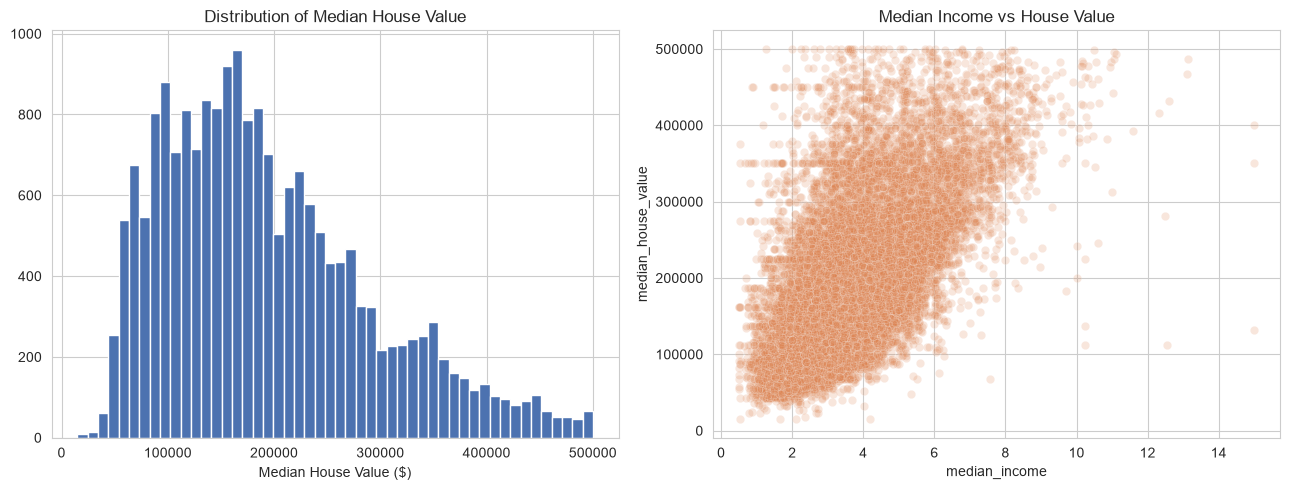

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['median_house_value'], bins=50, color='#4C72B0')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value ($)')

sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.2, ax=axes[1], color='#DD8452')
axes[1].set_title('Median Income vs House Value')
plt.tight_layout()
plt.show()

Median income shows a strong, clearly visible positive relationship with house value — likely to be one of the strongest predictors.

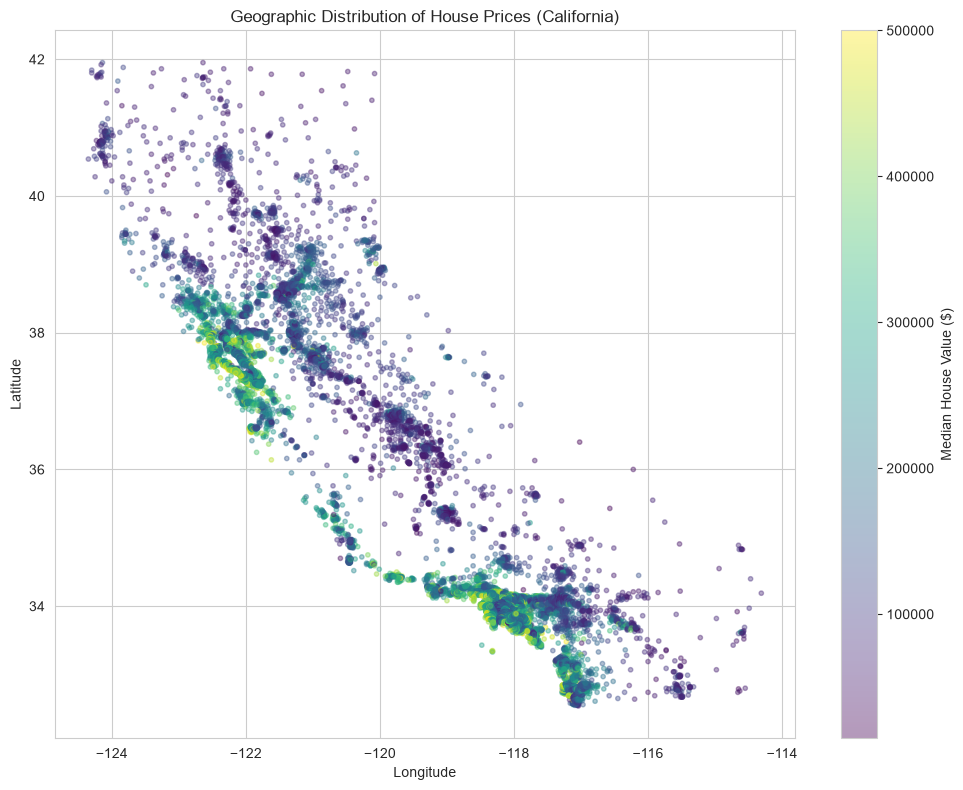

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(df['longitude'], df['latitude'], c=df['median_house_value'],
                 cmap='viridis', alpha=0.4, s=10)
plt.colorbar(sc, label='Median House Value ($)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution of House Prices (California)')
plt.tight_layout()
plt.show()

Prices cluster heavily along the coast (the bright band on the left/west side matches the SF Bay Area and LA/coastal Southern California) — location clearly matters a lot.

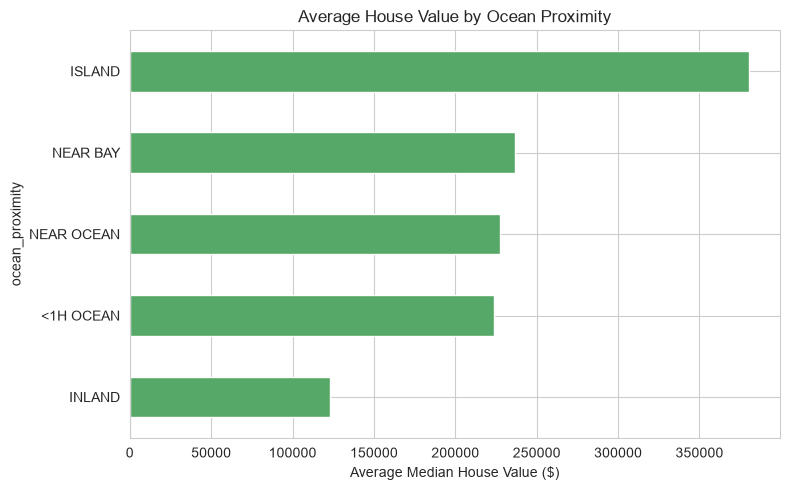

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby('ocean_proximity')['median_house_value'].mean().sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_xlabel('Average Median House Value ($)')
ax.set_title('Average House Value by Ocean Proximity')
plt.tight_layout()
plt.show()

In [10]:
corr = df.select_dtypes(include=[np.number]).corr()['median_house_value'].sort_values(ascending=False)
print("Correlation with target:")
print(corr)

Correlation with target:
median_house_value          1.000000
median_income               0.642611
total_rooms                 0.143139
rooms_per_household         0.109673
households                  0.094894
total_bedrooms              0.074179
housing_median_age          0.067948
population                  0.011964
population_per_household   -0.021465
longitude                  -0.046658
latitude                   -0.148289
bedrooms_per_room          -0.196119
Name: median_house_value, dtype: float64


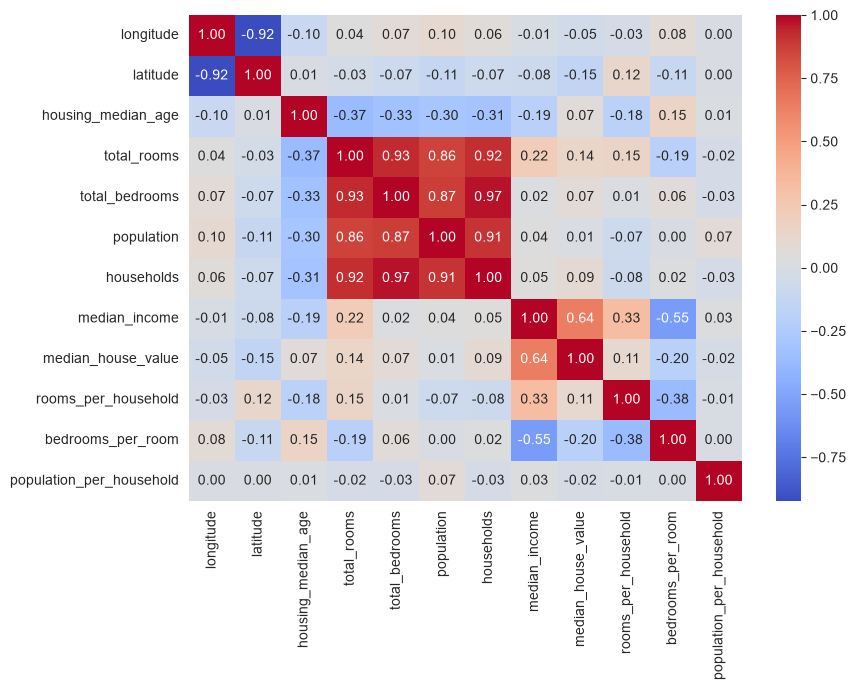

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
plt.tight_layout()
plt.show()

`median_income` (0.64) is by far the strongest numeric correlate. `bedrooms_per_room` has a meaningful *negative* correlation (-0.20) — areas with a higher bedroom-to-room ratio tend to be cheaper, likely reflecting smaller/older housing stock.

## 6. Preprocessing

- **`ocean_proximity`** (5 categories: `<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`) is one-hot encoded with `drop_first=True`.
- **Scaling**: `median_income` ranges 0–15 while `total_rooms` can be in the thousands — Linear/Ridge Regression coefficients and KNN's distance metric both need comparable scales, so we standardize numeric features for those models. Tree-based models (Decision Tree, Random Forest) don't need scaling.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)
print("Shape after encoding:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

numeric_cols = X.columns.tolist()
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

Shape after encoding: (19675, 15)
Train: (15740, 15), Test: (3935, 15)


## 7. Train 5 regression algorithms

- **Linear Regression** — simplest baseline, assumes a straight-line relationship
- **Ridge Regression** — linear regression with L2 regularization, more robust to correlated features
- **Decision Tree Regressor** — captures non-linear splits
- **Random Forest Regressor** — ensemble of trees, usually more robust
- **KNN Regressor** — predicts based on the average of the nearest neighbors

In [13]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression': (LinearRegression(), X_train_scaled, X_test_scaled),
    'Ridge Regression':  (Ridge(alpha=1.0, random_state=42), X_train_scaled, X_test_scaled),
    'Decision Tree':     (DecisionTreeRegressor(max_depth=10, random_state=42), X_train, X_test),
    'Random Forest':     (RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1), X_train, X_test),
    'KNN Regressor':     (KNeighborsRegressor(n_neighbors=10), X_train_scaled, X_test_scaled),
}

results = []
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2})
    print(f"{name:20s} | MAE: {mae:10.2f} | RMSE: {rmse:10.2f} | R2: {r2:.4f}")

Linear Regression    | MAE:   45480.93 | RMSE:   62205.84 | R2: 0.6119
Ridge Regression     | MAE:   45480.81 | RMSE:   62204.40 | R2: 0.6119
Decision Tree        | MAE:   38335.28 | RMSE:   57010.22 | R2: 0.6740
Random Forest        | MAE:   31194.78 | RMSE:   46613.55 | R2: 0.7821
KNN Regressor        | MAE:   38495.94 | RMSE:   55516.10 | R2: 0.6909


## 8. Evaluation — full comparison

- **MAE (Mean Absolute Error)**: average dollar error, easy to interpret
- **RMSE (Root Mean Squared Error)**: penalizes large errors more heavily
- **R² Score**: proportion of variance in house prices explained by the model (1.0 = perfect, 0 = no better than predicting the mean)

In [14]:
results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2 Score
0,Random Forest,31194.775880,46613.552191,0.782085
1,KNN Regressor,38495.939492,55516.104828,0.690899
2,Decision Tree,38335.284826,57010.223159,0.674038
3,Ridge Regression,45480.813642,62204.404003,0.611935
4,Linear Regression,45480.926818,62205.844110,0.611917


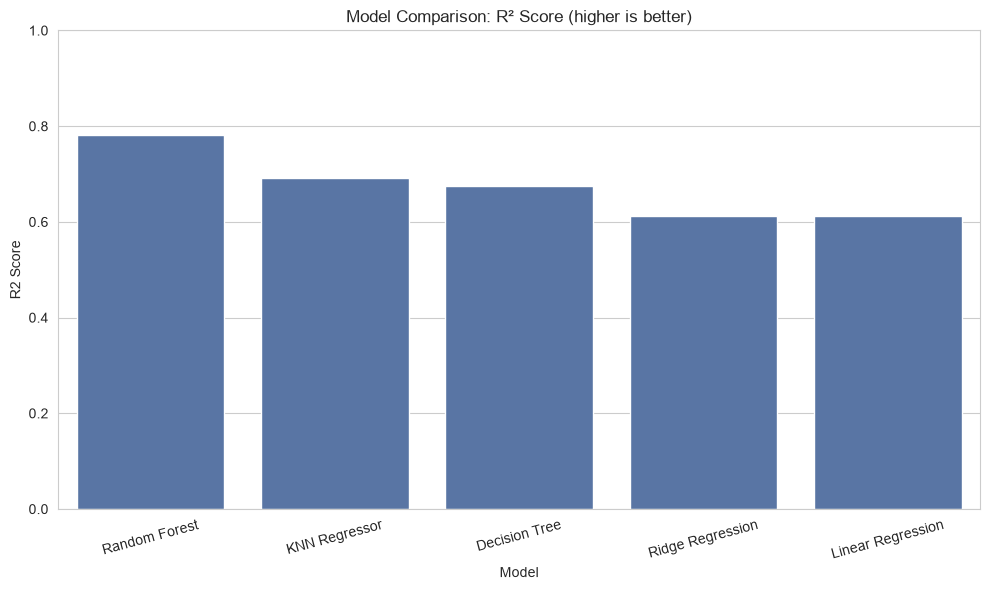

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='R2 Score', ax=ax, color='#4C72B0')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison: R² Score (higher is better)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

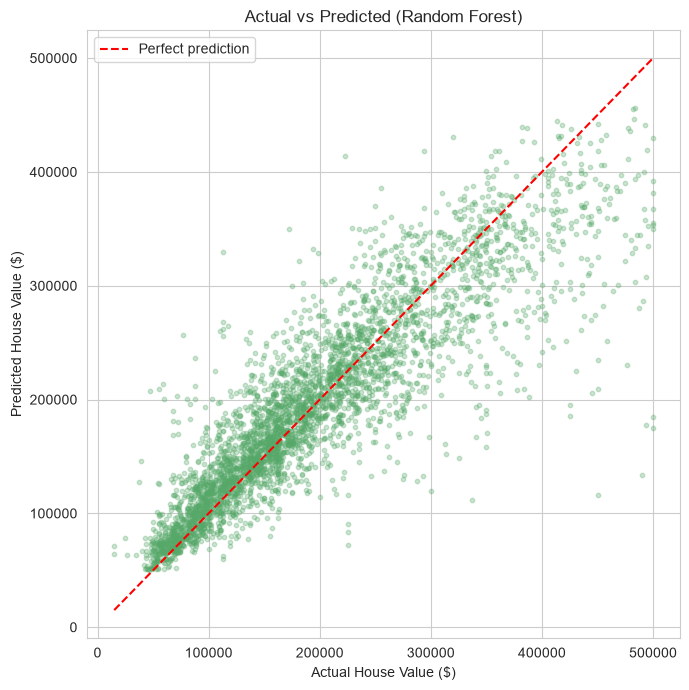

Best model: Random Forest


In [16]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name][0]
best_Xte = models[best_model_name][2]
preds_best = best_model.predict(best_Xte)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, preds_best, alpha=0.3, s=10, color='#55A868')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Actual House Value ($)')
ax.set_ylabel('Predicted House Value ($)')
ax.set_title(f'Actual vs Predicted ({best_model_name})')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Best model: {best_model_name}")

Points close to the red dashed line are well-predicted. The spread widens at higher prices — the model is more confident/accurate on mid-range homes than on the most expensive ones, which makes sense given fewer high-value examples to learn from.

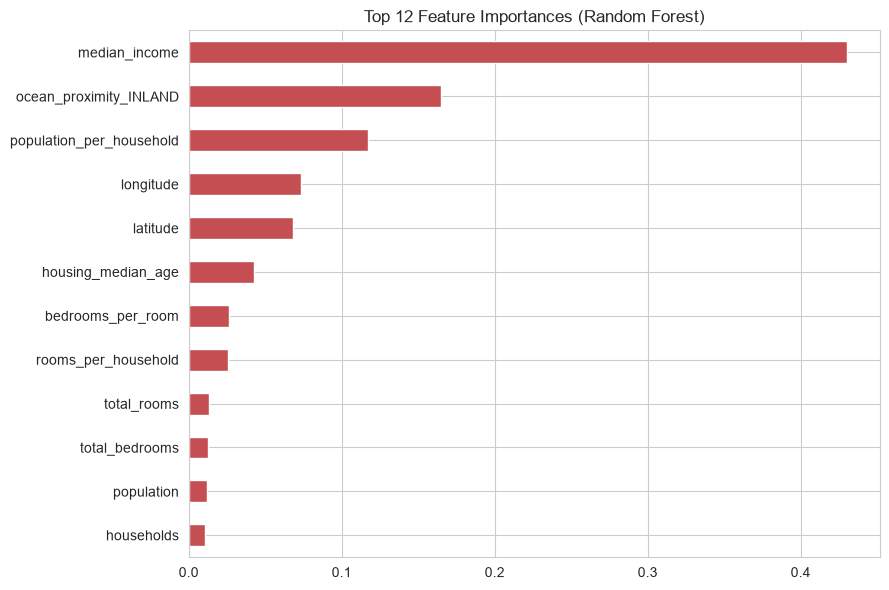

In [17]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(9, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='#C44E52')
ax.set_title(f'Top 12 Feature Importances ({best_model_name})')
plt.tight_layout()
plt.show()

## 9. Final Recommendation

| Model | MAE | RMSE | R² Score |
|---|---|---|---|
| **Random Forest** | **$31,195** | **$46,614** | **0.782** |
| KNN Regressor | $38,496 | $55,516 | 0.691 |
| Decision Tree | $38,335 | $57,010 | 0.674 |
| Ridge Regression | $45,481 | $62,204 | 0.612 |
| Linear Regression | $45,481 | $62,206 | 0.612 |

### Recommended model: **Random Forest**

It wins clearly on every metric — lowest error, highest R². Why it likely wins here:

- **Non-linear relationships.** House value doesn't move in a straight line with any single feature — e.g., the effect of `median_income` on price differs by location (coastal vs inland). Linear/Ridge Regression can only fit straight-line relationships, capping their R² around 0.61, while tree-based models capture these interactions naturally.
- **Location matters in a non-linear way.** `latitude`/`longitude` don't have a simple linear relationship with price (price spikes near the coast and in specific metro areas, not uniformly) — trees can carve out these irregular regions; a straight-line model can't.
- **Ensemble averaging beats a single tree.** A single Decision Tree already beats Linear Regression (R² 0.674 vs 0.612) but overfits to noise; Random Forest's averaging over 200 trees smooths this out for a meaningfully higher R².
- **Robust to the mixed feature scale.** Even though we scaled features for the linear/KNN models, Random Forest doesn't need scaling at all and isn't thrown off by very different feature ranges (e.g., `total_rooms` in the thousands vs `bedrooms_per_room` between 0 and 1).

### Caveat
Random Forest is harder to interpret than Linear Regression — if the "why" behind a prediction matters as much as accuracy (e.g., explaining to a homeowner why their house is valued a certain way), a simpler, more interpretable model, or feature-importance/SHAP explanations on top of the Random Forest, would be worth adding.